In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
data = pd.read_csv("12-health_risk_classification.csv")

In [4]:
# bmi_score -> Body Mass Index (standardized)
# blood_pressure_variation -> Fluctuation in systolic blood pressure
# activity_level_index -> Daily activity level (from wearable data, normalized)
# high_risk_flag -> 1 = High health risk, 0 = Low risk

In [5]:
data

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1
...,...,...,...,...
995,0.640158,-1.962795,-0.541917,0
996,-2.784745,2.717867,-1.894291,1
997,0.238598,0.840739,0.946540,1
998,-1.044982,-0.055455,-1.496340,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [7]:
data.isnull().sum()

bmi_score                   0
blood_pressure_variation    0
activity_level_index        0
high_risk_flag              0
dtype: int64

In [8]:
data.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


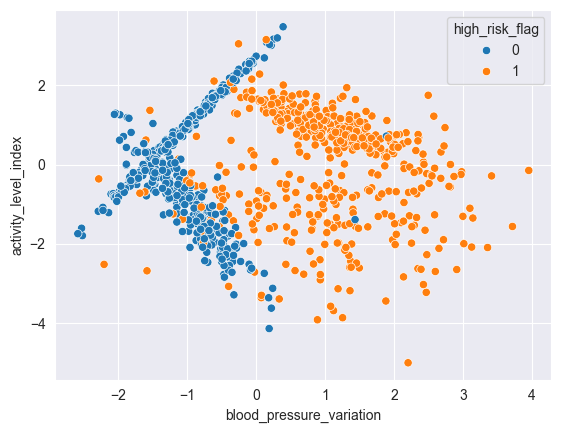

In [9]:
sns.scatterplot(x=data["blood_pressure_variation"], y=data["activity_level_index"], hue=data["high_risk_flag"])
plt.show()

In [11]:
# balance or inbalence data?
data["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [12]:
X = data.drop("high_risk_flag", axis = 1)
y = data["high_risk_flag"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

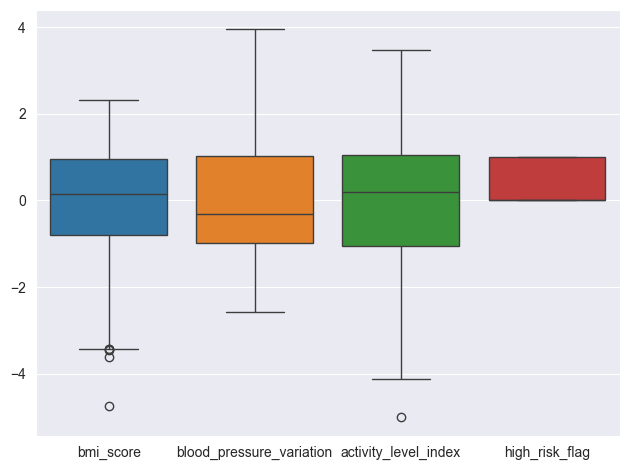

In [15]:
sns.boxplot(data)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [30]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.neighbors import KNeighborsClassifier

In [32]:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='auto', weights='uniform')

In [33]:
classifier.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
y_pred = classifier.predict(X_test_scaled)

In [35]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [36]:
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Accuracy: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

Confusion Matrix: 
 [[124  10]
 [  2 114]]
Accuracy:  0.952
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [37]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree', weights='uniform')
classifier.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
y_pred = classifier.predict(X_test_scaled)
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Accuracy: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

Confusion Matrix: 
 [[124  10]
 [  2 114]]
Accuracy:  0.952
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [47]:
classifier = KNeighborsClassifier(n_neighbors=3, algorithm='kd_tree', weights='uniform')
classifier.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [48]:
y_pred = classifier.predict(X_test_scaled)
print("Confusion Matrix: \n", confusion_matrix(y_pred, y_test))
print("Accuracy: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

Confusion Matrix: 
 [[125   9]
 [  1 115]]
Accuracy:  0.96
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250

